<a href="https://colab.research.google.com/github/HoaiPhuong-Nguyen/AIHC5020/blob/main/homework5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q wfdb


In [2]:
!pip uninstall -y wfdb

Found existing installation: wfdb 4.1.2
Uninstalling wfdb-4.1.2:
  Successfully uninstalled wfdb-4.1.2


In [4]:
!pip install wfdb==4.1.2 pandas==2.2.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 3.7 MB/s eta 0:00:00


In [5]:
from google.colab import drive

# Start the mounting process
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!ls "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"

100.atr    106.dat  113.hea  119.hea  202.atr  209.xws	217.xws  230.atr
100.dat    106.hea  113.xws  119.xws  202.dat  210.atr	219.atr  230.dat
100.hea    106.xws  114.atr  121.atr  202.hea  210.dat	219.dat  230.hea
100.xws    107.atr  114.dat  121.dat  202.xws  210.hea	219.hea  230.xws
101.atr    107.dat  114.hea  121.hea  203.at-  210.xws	219.xws  231.atr
101.dat    107.hea  114.xws  121.xws  203.at_  212.atr	220.atr  231.dat
101.hea    107.xws  115.atr  122.atr  203.atr  212.dat	220.dat  231.hea
101.xws    108.at_  115.dat  122.dat  203.dat  212.hea	220.hea  231.xws
102-0.atr  108.atr  115.hea  122.hea  203.hea  212.xws	220.xws  232.atr
102.atr    108.dat  115.xws  122.xws  203.xws  213.atr	221.atr  232.dat
102.dat    108.hea  116.atr  123.atr  205.atr  213.dat	221.dat  232.hea
102.hea    108.xws  116.dat  123.dat  205.dat  213.hea	221.hea  232.xws
102.xws    109.atr  116.hea  123.hea  205.hea  213.xws	221.xws  233.atr
103.atr    109.dat  116.xws  123.xws  205.xws  214.at_	222.at_  

In [1]:
import os

wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"
print(os.listdir(wfdb_root))        # should list record numbers (100, 101, …)
print(os.listdir(f"{wfdb_root}"))  # should show .dat, .hea, .atr

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb'

In [11]:
import os

wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"
print([f for f in os.listdir(wfdb_root) if f.startswith("101")])

['101.hea', '101.atr', '101.dat', '101.xws']


In [19]:
#Problem 1
import wfdb
import pandas as pd
import os

def load_ecg_data(record_number, max_duration, wfdb_root):
  record_number = str(record_number)
  record_path = os.path.join(wfdb_root, record_number)

  # Load waveform
  ecg_record = wfdb.rdrecord(record_path)
  fs = int(ecg_record.fs)
  cutoff_sample_index = int(max_duration * fs)

  # ECG DataFrame
  ecg_df = pd.DataFrame(
      data=ecg_record.p_signal[:cutoff_sample_index],
      columns=ecg_record.sig_name
  )
  ecg_df["sample_index"] = range(len(ecg_df))

  # Try reading annotation
  annotations_df = pd.DataFrame(columns=["annotation_index", "annotation_text"])
  try:
      ann = wfdb.rdann(record_path, "atr", ignore_skew=True)
      annotations_df = pd.DataFrame({
          "annotation_index": ann.sample,
          "annotation_text": ann.symbol
      })
      annotations_df = annotations_df[annotations_df["annotation_index"] < cutoff_sample_index]
  except Exception as e:
      #print(f"⚠️ Could not read annotations for {record_number}: {e}")
      annotations_df = pd.DataFrame(columns=["annotation_index", "annotation_text"])

  return ecg_df, annotations_df, fs

In [20]:
# Testing Problem 1

wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"
ecg_df_101, annotations_df_101, fs_101 = load_ecg_data(101, 15, wfdb_root)

print("Sample rate:", fs_101)

# Show last 5 rows of ECG signal
print("\nECG DataFrame (last 5 rows):")
print(ecg_df_101.tail())
# Show last 5 rows of annotations
print("\nAnnotation DataFrame (last 5 rows):")
print(annotations_df_101.tail())

Sample rate: 360

ECG DataFrame (last 5 rows):
       MLII     V1  sample_index
5395 -0.275 -0.035          5395
5396 -0.250 -0.015          5396
5397 -0.245 -0.005          5397
5398 -0.245  0.005          5398
5399 -0.250  0.000          5399

Annotation DataFrame (last 5 rows):
Empty DataFrame
Columns: [annotation_index, annotation_text]
Index: []


In [12]:
import os

wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"
print([f for f in os.listdir(wfdb_root) if f.startswith("101")])

['101.hea', '101.atr', '101.dat', '101.xws']


In [21]:
#Problem 2
import matplotlib.pyplot as plt

def plot_ecg_segment(ecg_df, annotations_df, channel_name, start_index, end_index):
     # --- Filter the data ---
    if channel_name not in ecg_df.columns:
        raise ValueError(f"Channel '{channel_name}' not found. Available: {ecg_df.columns.tolist()}")

    ecg_segment = ecg_df.loc[start_index:end_index, channel_name]
    ann_segment = annotations_df[
        (annotations_df["annotation_index"] >= start_index) &
        (annotations_df["annotation_index"] <= end_index)
    ]

    # Create the plot
    plt.figure(figsize=(20, 6))
    plt.plot(ecg_segment.index, ecg_segment.values, label=channel_name, color="black")

    # Overlay annotations
    for _, row in ann_segment.iterrows():
        ann_idx = row["annotation_index"]
        ann_text = row["annotation_text"]
        plt.axvline(x=ann_idx, color="red", linestyle="--", alpha=0.7)
        plt.text(
            ann_idx,
            ecg_segment.max() * 1.05,  # just above the waveform
            ann_text,
            color="red",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    # Finalize plot
    plt.title(f"ECG Channel: {channel_name} | Samples {start_index}–{end_index}", fontsize=14)
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.show()

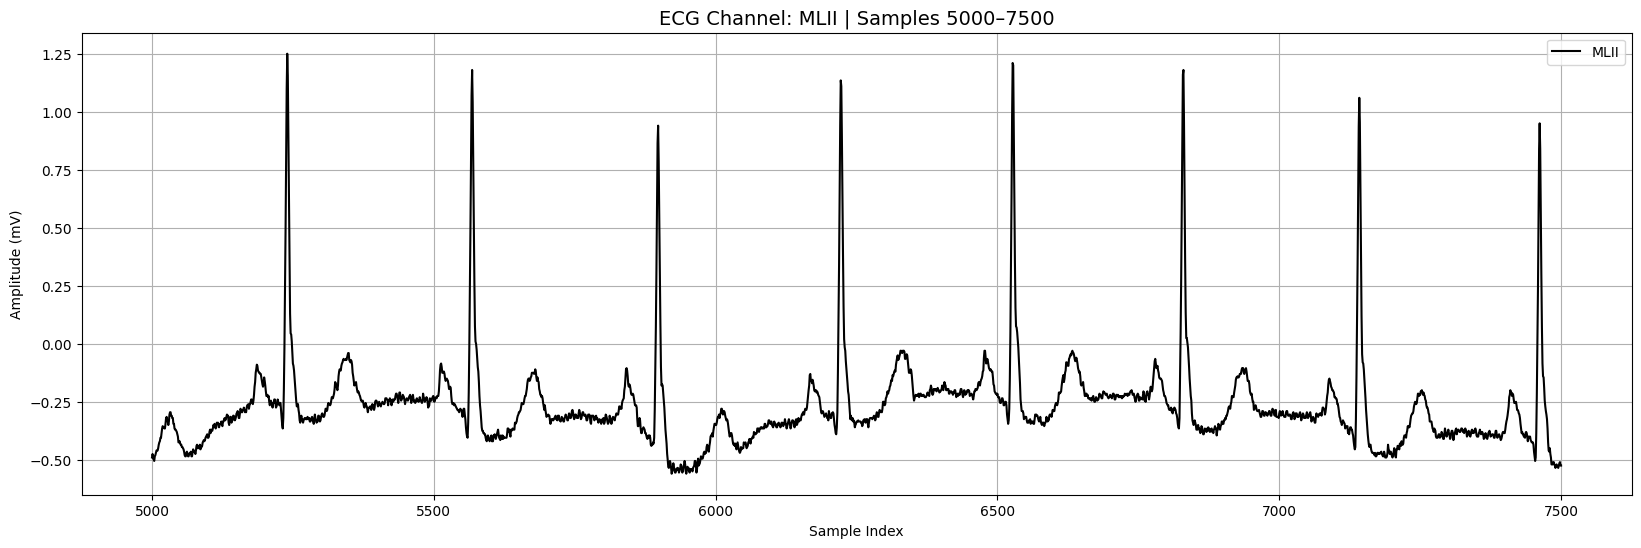

In [22]:
#Testing Problem 2
wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"
ecg_df_101, annotations_df_101, fs_101 = load_ecg_data(101, 30, wfdb_root)

# Plot a segment of the MLII channel from sample 5000 to 7500
plot_ecg_segment(
    ecg_df=ecg_df_101,
    annotations_df=annotations_df_101,
    channel_name="MLII",
    start_index=5000,
    end_index=7500
)

In [23]:
#Problem 3
import numpy as np
import pandas as pd

def create_segment_table(record_number, max_duration, wfdb_root, segment_duration):
    # Load ECG data (Problem 1 function assumed available)
    ecg_df, annotations_df, fs = load_ecg_data(record_number, max_duration, wfdb_root)

    # Calculate number of samples and segments
    n_samples_total = len(ecg_df)
    samples_per_segment = segment_duration * fs
    n_segments = int(np.ceil(n_samples_total / samples_per_segment))

    # Split data + index into segments
    data_segments = np.array_split(ecg_df.values, n_segments)
    index_segments = np.array_split(ecg_df.index.values, n_segments)

    # Build rows for segment table
    rows = []
    for seg_idx, (seg_data, seg_index) in enumerate(zip(data_segments, index_segments)):
        for ch_idx, channel_name in enumerate(ecg_df.columns):
            row = {
                "record_number": record_number,
                "segment_index": seg_idx,
                "sample_rate": fs,
                "n_samples": len(seg_index),
                "channel_name": channel_name,
                "segment_start_index": int(seg_index[0]),
                "segment": seg_data[:, ch_idx]  # array of values for this channel
            }
            rows.append(row)

    # Convert to DataFrame
    segment_table = pd.DataFrame(rows)
    return segment_table

In [24]:
#Testing Problem 3
wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"

segment_table_100 = create_segment_table(
    record_number=100,
    max_duration=30,      # 30 seconds max
    wfdb_root=wfdb_root,
    segment_duration=4    # 4-second segments
)

print(segment_table_100.head(10))
print("Shape of segment table:", segment_table_100.shape)

   record_number  segment_index  sample_rate  n_samples  channel_name  \
0            100              0          360       1350          MLII   
1            100              0          360       1350            V5   
2            100              0          360       1350  sample_index   
3            100              1          360       1350          MLII   
4            100              1          360       1350            V5   
5            100              1          360       1350  sample_index   
6            100              2          360       1350          MLII   
7            100              2          360       1350            V5   
8            100              2          360       1350  sample_index   
9            100              3          360       1350          MLII   

   segment_start_index                                            segment  
0                    0  [-0.145, -0.145, -0.145, -0.145, -0.145, -0.14...  
1                    0  [-0.065, -0.065, -0.

In [25]:
!pip install -q pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.1 MB/s eta 0:00:00


In [32]:
# Problem 4
import os
from pathlib import Path
import pydicom
import pandas as pd

def create_dicom_manifest(root_dir: str):
    root_path = Path(root_dir)
    series_list = []

    # Walk through the folder structure
    for series_path in root_path.rglob("*"):
        if not series_path.is_dir():
            continue

        # Check if this folder contains .dcm files (then it's a series folder)
        dcm_files = list(series_path.glob("*.dcm"))
        if len(dcm_files) == 0:
            continue

        # Use first .dcm file for metadata
        sample_file = dcm_files[0]
        try:
            ds = pydicom.dcmread(str(sample_file), stop_before_pixels=True)
        except Exception as e:
            print(f"⚠️ Could not read {sample_file}: {e}")
            continue

        # Extract metadata with safe fallbacks
        patient_id = getattr(ds, "PatientID", "N/A")
        study_date = getattr(ds, "StudyDate", "N/A")
        modality = getattr(ds, "Modality", "N/A")
        series_description = getattr(ds, "SeriesDescription", "N/A")
        study_instance_uid = getattr(ds, "StudyInstanceUID", "N/A")
        series_instance_uid = getattr(ds, "SeriesInstanceUID", "N/A")

        # Append result
        series_list.append({
            "patient_id": patient_id,
            "study_date": study_date,
            "modality": modality,
            "series_description": series_description,
            "n_images": len(dcm_files),
            "study_instance_uid": study_instance_uid,
            "series_instance_uid": series_instance_uid,
            "series_path": str(series_path)
        })

    # ✅ Make sure return is OUTSIDE the loop
    manifest_df = pd.DataFrame(series_list)
    return manifest_df


In [33]:
# Testing Problem 4
dicom_root = "/content/drive/MyDrive/AIHC5020/dicom/tcia/LIDC-IDRI"

manifest_df = create_dicom_manifest(dicom_root)

print("Number of series found:", len(manifest_df))
print(manifest_df.head())

Number of series found: 92
       patient_id study_date modality  \
0  LIDC-IDRI-0006   20000101       DX   
1  LIDC-IDRI-0006   20000101      SEG   
2  LIDC-IDRI-0006   20000101      SEG   
3  LIDC-IDRI-0006   20000101       CT   
4  LIDC-IDRI-0006   20000101      SEG   

                                  series_description  n_images  \
0                                                N/A         2   
1   Segmentation of Nodule 1 - Annotation Nodule 003         1   
2  Segmentation of Nodule 2 - Annotation MI014_16363         1   
3                                                N/A       133   
4           Segmentation of Nodule 3 - Annotation 17         1   

                                  study_instance_uid  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.618422555692...   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006

In [34]:
# Problem 5
import pydicom
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def visualize_ct_series(manifest_row):
  # Validation
    if manifest_row["modality"] != "CT":
        raise ValueError("This function only works with CT series (modality must be 'CT').")
    if manifest_row["n_images"] <= 1:
        raise ValueError("Series must contain more than 1 image (not a derived single-image series).")

    # Load all slices in the series
    series_path = Path(manifest_row["series_path"])
    dcm_files = sorted(series_path.glob("*.dcm"))

    slices = []
    for f in dcm_files:
        try:
            ds = pydicom.dcmread(str(f))
            instance_number = getattr(ds, "InstanceNumber", None)
            if instance_number is not None:
                slices.append((instance_number, ds))
        except Exception as e:
            print(f"⚠️ Skipping {f}: {e}")

    # Sort slices by InstanceNumber
    slices.sort(key=lambda x: x[0])

    if len(slices) == 0:
        raise ValueError("No valid slices with InstanceNumber found in this series.")

    # Pick 4 evenly spaced slice indices
    n = len(slices)
    indices = [int(n * frac) for frac in [0.2, 0.4, 0.6, 0.8]]
    selected_slices = [slices[i][1] for i in indices]

    # Create montage plot
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    for ax, ds, idx in zip(axs, selected_slices, indices):
        ax.imshow(ds.pixel_array, cmap="gray")
        ax.set_title(f"Slice {idx} (Instance {ds.InstanceNumber})")
        ax.set_axis_off()

    # Figure title with patient info
    fig.suptitle(f"Patient: {manifest_row['patient_id']} | Study Date: {manifest_row['study_date']}", fontsize=16)
    plt.tight_layout()
    plt.show()


In [35]:
print(manifest_df.columns.tolist())
print(manifest_df.head())

['patient_id', 'study_date', 'modality', 'series_description', 'n_images', 'study_instance_uid', 'series_instance_uid', 'series_path']
       patient_id study_date modality  \
0  LIDC-IDRI-0006   20000101       DX   
1  LIDC-IDRI-0006   20000101      SEG   
2  LIDC-IDRI-0006   20000101      SEG   
3  LIDC-IDRI-0006   20000101       CT   
4  LIDC-IDRI-0006   20000101      SEG   

                                  series_description  n_images  \
0                                                N/A         2   
1   Segmentation of Nodule 1 - Annotation Nodule 003         1   
2  Segmentation of Nodule 2 - Annotation MI014_16363         1   
3                                                N/A       133   
4           Segmentation of Nodule 3 - Annotation 17         1   

                                  study_instance_uid  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.618422555692...   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006... 

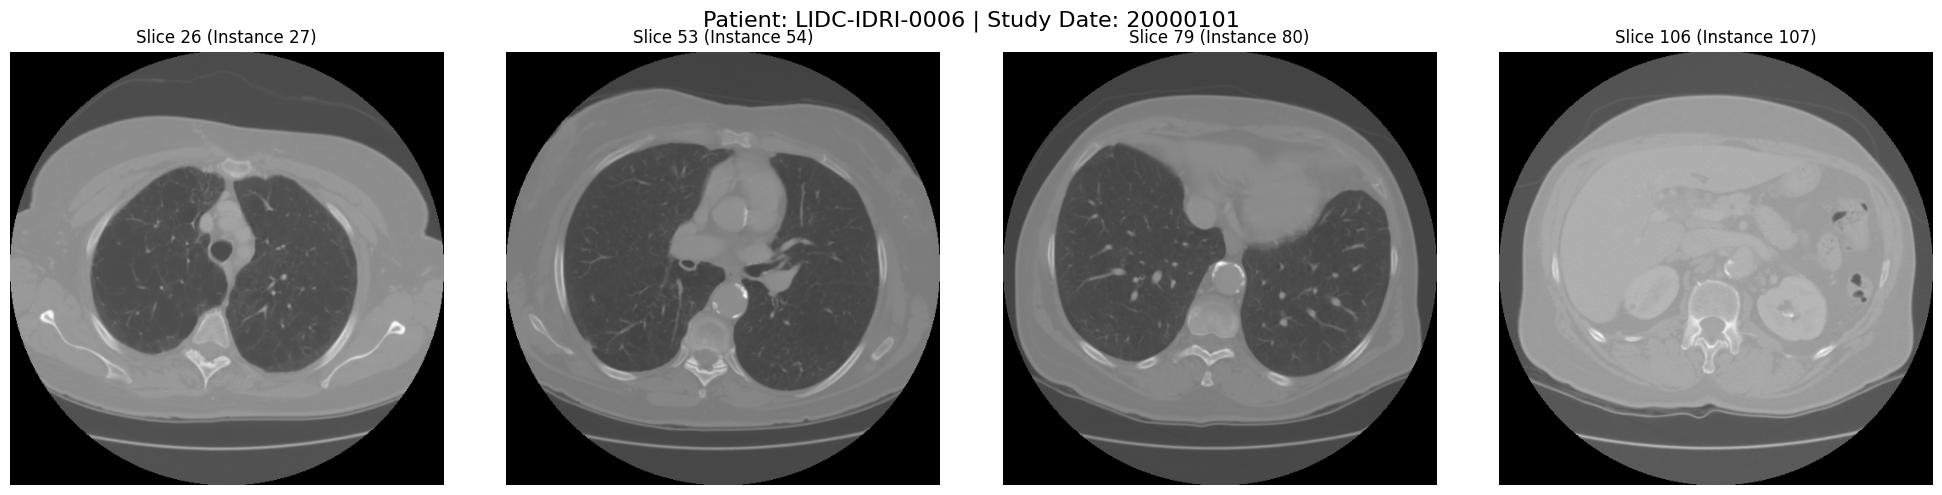

In [36]:
ct_row = manifest_df[(manifest_df["modality"] == "CT") & (manifest_df["n_images"] > 1)].iloc[0]

visualize_ct_series(ct_row)